In [1]:
# E={(11,0.8),(11.6,1),(9.2,0.9),(14.1,0.8),(13.4,0.9),(8.8,1.1),(12.2,0.8)}
# Use covariance elliptic envelope to determine if x_8=(13.9,1.1) is an outlier.

import numpy as np
from sklearn.covariance import EllipticEnvelope
# Define the data points
E = np.array([[11, 0.8], [11.6, 1], [9.2, 0.9], [14.1, 0.8], [13.4, 0.9], [8.8, 1.1], [12.2, 0.8]])
# Define the point to check
x_8 = np.array([[13.9, 1.1]])
# Fit the EllipticEnvelope model
envelope = EllipticEnvelope(contamination=0.1)
envelope.fit(E)
# Predict if x_8 is an outlier
is_outlier = envelope.predict(x_8)
# Print the result
if is_outlier[0] == -1:
    print("x_8 is an outlier.")
else:
    print("x_8 is not an outlier.")

x_8 is an outlier.


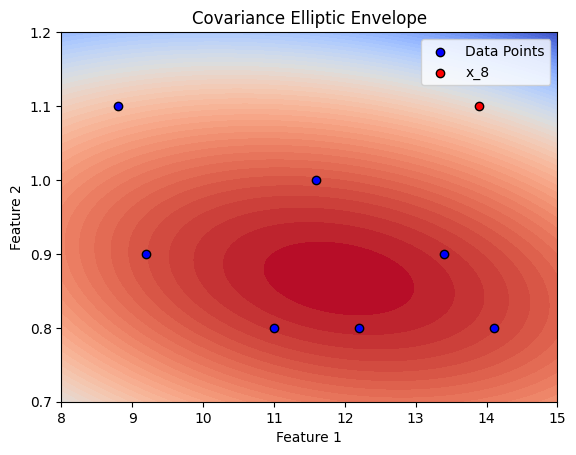

In [2]:
# Plot the data points and the point x_8 and the decision boundary of the EllipticEnvelope
import matplotlib.pyplot as plt
# Create a grid of points to evaluate the decision function
xx, yy = np.meshgrid(np.linspace(8, 15, 100), np.linspace(0.7, 1.2, 100))
Z = envelope.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
# Plot the decision boundary and the data points
plt.contourf(xx, yy, Z, levels=50, cmap='coolwarm')
plt.scatter(E[:, 0], E[:, 1], c='blue', edgecolor='k', label='Data Points')
plt.scatter(x_8[0, 0], x_8[0, 1], c='red', edgecolor='k', label='x_8')
plt.legend()
plt.title('Covariance Elliptic Envelope')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()